In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import seaborn as sns
from scipy.integrate import quad
import torch
from torch import nn
from datetime import datetime
from matplotlib.gridspec import GridSpec
from tensorboard.backend.event_processing import event_accumulator

from copy import deepcopy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CallbackList, EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../../")

In [3]:
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.agents.BaselineAgents import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *

# helpers
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.index_names import *
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.wrappers import *

In [4]:
seed_value = 5
global seed  
seed = seed_value

# Reset seeds for all randomness sources
np.random.seed(seed)
torch.manual_seed(seed)

### Parameters

In [5]:
max_inventory = 20

In [6]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 100
initial_inventory = 0
fads_proportion = 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
fill_exponent = k
gamma = k
alpha=0.001
mu=0
big_phi=0.1

In [7]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(q):
    c = gamma * sigma * q
    def integrand(t):
        return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

# compute psi for each fad proportion
psi = compute_psi(fads_proportion)

print("psi value:", psi)

psi value: 14.872283180889763


In [8]:
def get_closed_form_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [9]:
cj_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [10]:
cj_agent = ModifiedCarteaJaimungalMmAgent(env=cj_env)
print(cj_env.model_dynamics
      .midprice_model)


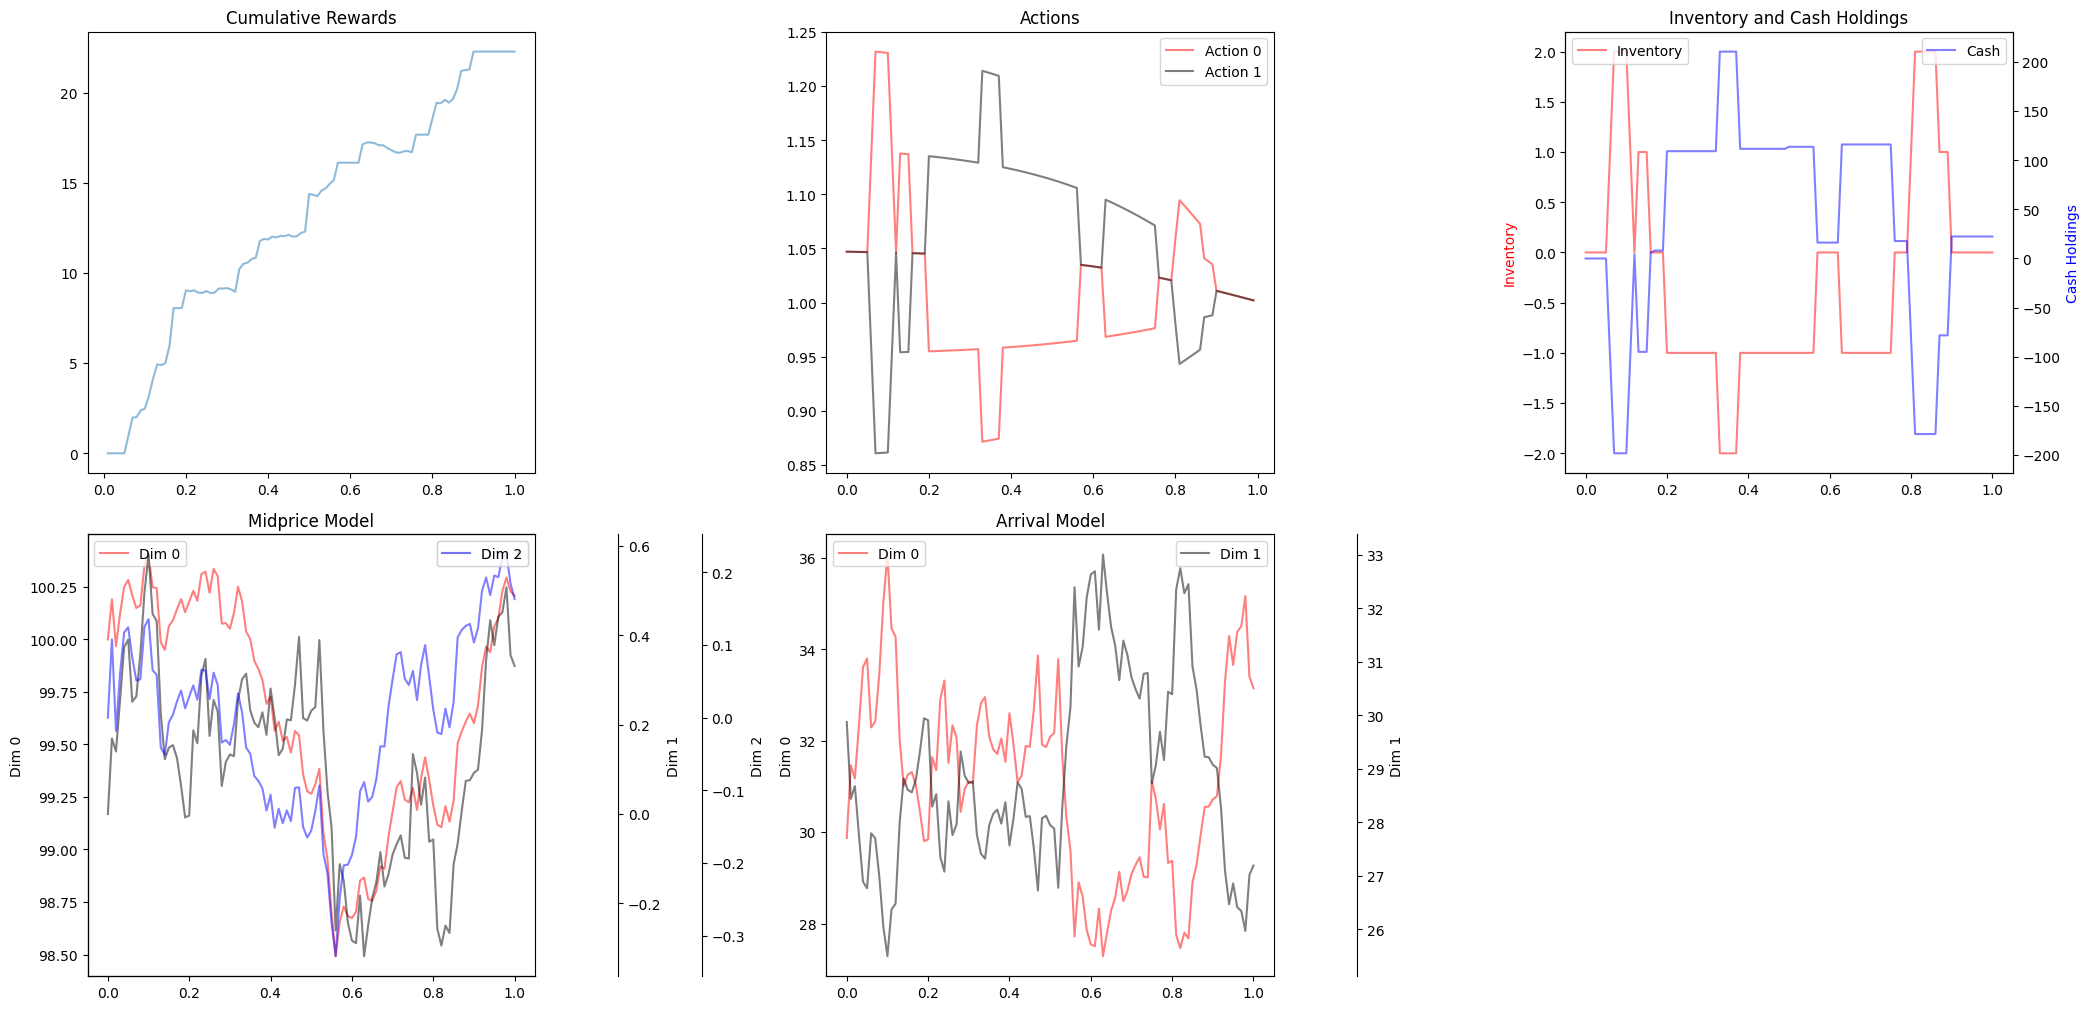

In [11]:
plot_trajectory_extended(cj_env, cj_agent)

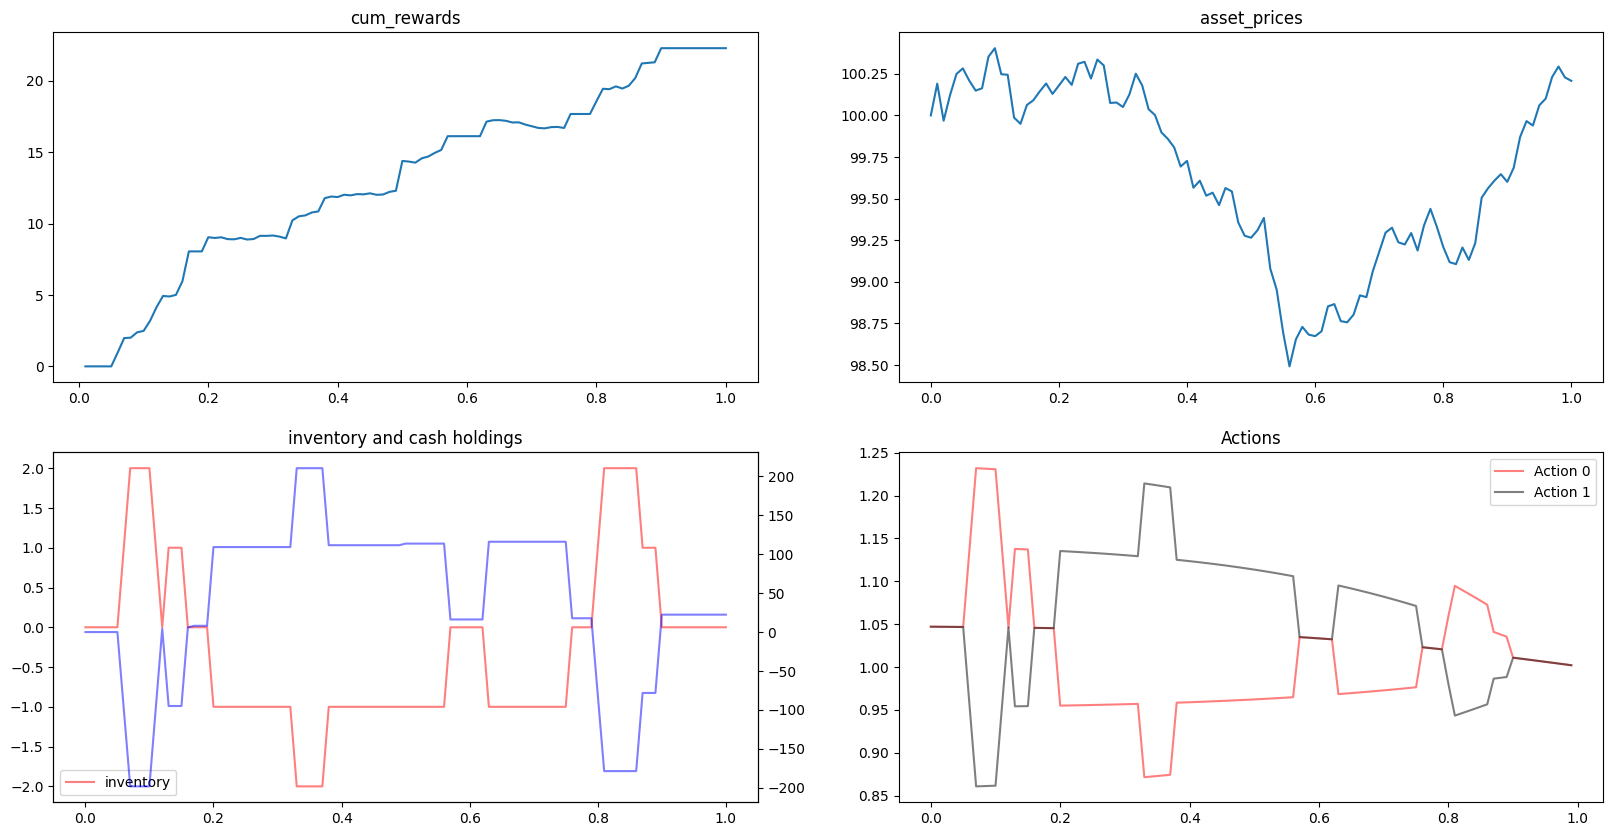

In [12]:
plot_trajectory(cj_env, cj_agent, seed = seed)

In [13]:
num_trajectories = 1000
vec_cj_env = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_cj = ModifiedCarteaJaimungalMmAgent(env=vec_cj_env)

print(vec_cj_env.model_dynamics
      .midprice_model)

In [14]:
observations_cj, actions_cj, rewards_cj = generate_trajectory(vec_cj_env, vec_cj)

In [15]:
results_cj, fig_cj, total_rewards_cj = generate_results_table_and_hist(vec_env=vec_cj_env,agent=vec_cj)

In [16]:
results_cj

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.06632,21.487223,4.845374,-0.095,2.909291


### Rinforncement Learning

In [17]:
def compute_cj_distance_score(inventories, rl_bid, rl_ask, cj_bid, cj_ask):
    """
    Compute the CJ-Distance Score as the sum of absolute differences
    between RL and CJ spreads across all inventory levels.
    """
    bid_distance = np.sum(np.abs(np.array(rl_bid) - np.array(cj_bid)))
    ask_distance = np.sum(np.abs(np.array(rl_ask) - np.array(cj_ask)))
    total_distance = bid_distance + ask_distance
    
    return {
        'total_distance': total_distance,
        'bid_distance': bid_distance,
        'ask_distance': ask_distance
    }

In [18]:
def get_rl_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0, n_steps:int = n_steps
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      #initial_inventory = random_initial_inventory,
                      #start_time = make_random_start_time_sampler(terminal_time),
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [19]:
def get_rl_env_visualization(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0, n_steps:int = n_steps
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      #initial_inventory = random_initial_inventory,
                      #start_time = make_random_start_time_sampler(terminal_time),
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory = max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [20]:
total_steps = 1_000_000  
#eval_freq = total_steps // 10 
n_eval_episodes = 256

In [21]:
from stable_baselines3.common.callbacks import BaseCallback

class EntropyDecayCallback(BaseCallback):
    def __init__(self, initial_ent_coef=0.05, final_ent_coef=0.001, decay_steps=10_000_000, verbose=0):
        super().__init__(verbose)
        self.initial_ent_coef = initial_ent_coef
        self.final_ent_coef = final_ent_coef
        self.decay_steps = decay_steps

    def _on_step(self) -> bool:
        progress = min(1.0, self.num_timesteps / self.decay_steps)
        new_ent_coef = self.initial_ent_coef * (1 - progress) + self.final_ent_coef * progress
        self.model.ent_coef = new_ent_coef
        return True

In [22]:
use_normalized_agent = False


Testing n_steps = 10

Using cpu device


/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:225: RuntimeWarning: overflow encountered in cast
  elif low.dtype != self.dtype and np.any(low < dtype_min):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:295: RuntimeWarning: overflow encountered in cast
  elif high.dtype != self.dtype and np.any(dtype_max < high):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


Logging to .././CJ_models/tensorboard/PPO-learning/CjMm_PPO_systematic_n_steps_10/2025-12-05_10-24-26/PPO_1
-------------------------------
| time/              |        |
|    fps             | 151627 |
|    iterations      | 1      |
|    time_elapsed    | 0      |
|    total_timesteps | 100000 |
-------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 41655       |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 200000      |
| train/                  |             |
|    approx_kl            | 0.009540975 |
|    clip_fraction        | 0.122       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.86       |
|    explained_variance   | 0.00384     |
|    learning_rate        | 0.0003      |
|    loss                 | 0.719       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0103   

/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:225: RuntimeWarning: overflow encountered in cast
  elif low.dtype != self.dtype and np.any(low < dtype_min):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:295: RuntimeWarning: overflow encountered in cast
  elif high.dtype != self.dtype and np.any(dtype_max < high):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


-------------------------------
| time/              |        |
|    fps             | 357035 |
|    iterations      | 1      |
|    time_elapsed    | 0      |
|    total_timesteps | 100000 |
-------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 47125       |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 200000      |
| train/                  |             |
|    approx_kl            | 0.008087922 |
|    clip_fraction        | 0.0887      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.86       |
|    explained_variance   | 0.00784     |
|    learning_rate        | 0.0003      |
|    loss                 | 1.25        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00835    |
|    std                  | 1.01        |
|    value_loss           | 3.05        |
--------------------

...

-------------------------------
| time/              |        |
|    fps             | 409280 |
|    iterations      | 1      |
|    time_elapsed    | 0      |
|    total_timesteps | 100000 |
-------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 47015       |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 200000      |
| train/                  |             |
|    approx_kl            | 0.003350905 |
|    clip_fraction        | 0.0277      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.86       |
|    explained_variance   | -0.00441    |
|    learning_rate        | 0.0003      |
|    loss                 | 0.193       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00126    |
|    std                  | 1.02        |
|    value_loss           | 0.683       |
--------------------

/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:225: RuntimeWarning: overflow encountered in cast
  elif low.dtype != self.dtype and np.any(low < dtype_min):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:295: RuntimeWarning: overflow encountered in cast
  elif high.dtype != self.dtype and np.any(dtype_max < high):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


-------------------------------
| time/              |        |
|    fps             | 399617 |
|    iterations      | 1      |
|    time_elapsed    | 0      |
|    total_timesteps | 100000 |
-------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 47174        |
|    iterations           | 2            |
|    time_elapsed         | 4            |
|    total_timesteps      | 200000       |
| train/                  |              |
|    approx_kl            | 0.0028990172 |
|    clip_fraction        | 0.0258       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.86        |
|    explained_variance   | 0.000392     |
|    learning_rate        | 0.0003       |
|    loss                 | -0.0551      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.000795    |
|    std                  | 1.03         |
|    value_loss           | 0.19         |
--

/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:225: RuntimeWarning: overflow encountered in cast
  elif low.dtype != self.dtype and np.any(low < dtype_min):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:295: RuntimeWarning: overflow encountered in cast
  elif high.dtype != self.dtype and np.any(dtype_max < high):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


-------------------------------
| time/              |        |
|    fps             | 393293 |
|    iterations      | 1      |
|    time_elapsed    | 0      |
|    total_timesteps | 100000 |
-------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 47218       |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 200000      |
| train/                  |             |
|    approx_kl            | 0.001953785 |
|    clip_fraction        | 0.0198      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.86       |
|    explained_variance   | 0.0134      |
|    learning_rate        | 0.0003      |
|    loss                 | -0.106      |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.000482   |
|    std                  | 1.03        |
|    value_loss           | 0.0827      |
--------------------

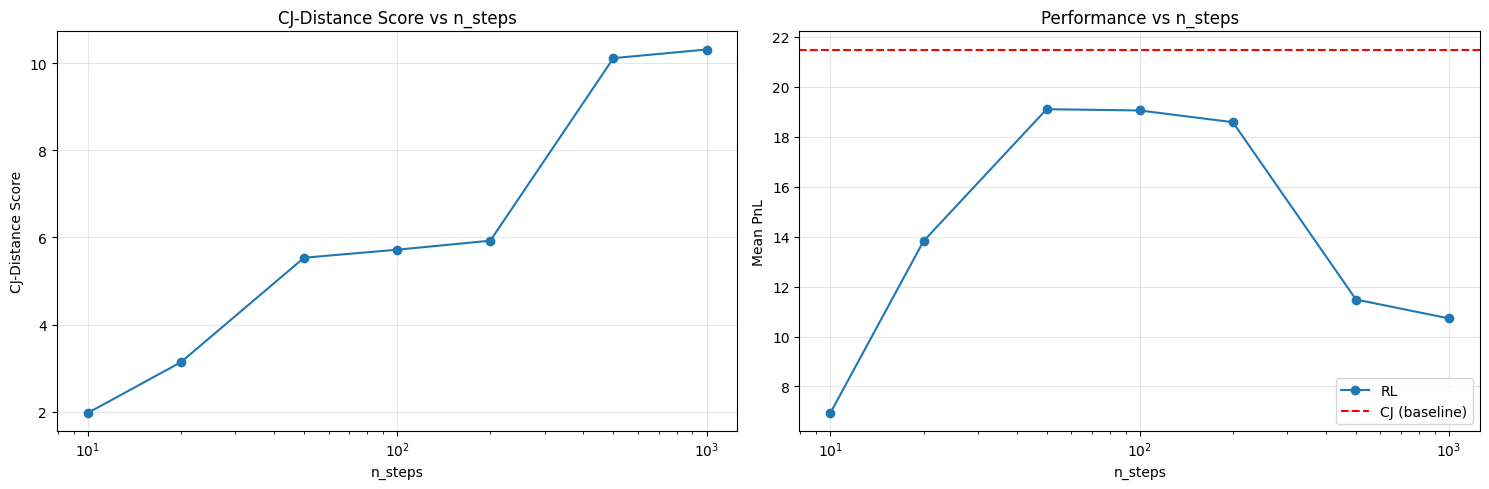

In [23]:
# Define the range of n_steps to test
n_steps_candidates = [10, 20, 50, 100, 200, 500, 1000]

results_summary = []

for n_steps_test in n_steps_candidates:
    print(f"\n{'='*60}")
    print(f"Testing n_steps = {n_steps_test}")
    print(f"{'='*60}\n")
    
    
    # 2. Recompute psi with new n_steps (if needed)
    psi = compute_psi(fads_proportion)
    
    # 3. Create new environment and train PPO
    num_trajectories = 1000
    reduced_training_indices = [INVENTORY_INDEX, TIME_INDEX, ASSET_PRICE_INDEX]
    rl_env = ReduceStateSizeWrapper(get_rl_env(num_trajectories, n_steps=n_steps_test), reduced_training_indices)
    sb_rl_env = StableBaselinesTradingEnvironment(trading_env=rl_env)

    # Generate timestamp string
    run_id = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    experiment_name = f"CjMm_PPO_systematic_n_steps_{n_steps_test}"
    # Paths with timestamp
    tensorboard_logdir = f".././CJ_models/tensorboard/PPO-learning/{experiment_name}/{run_id}/"
    best_model_path = f".././CJ_models/PPO-best/{experiment_name}/{run_id}/"


    policy_kwargs = dict(
        activation_fn=nn.Tanh,                 
        net_arch=[dict(pi=[256, 256], vf=[256, 256])]
    )

    n_epochs = 10
    learning_rate = 3e-4
    gae_lambda = 0.95
    clip_range = 0.2
    vf_coef = 0.5
    max_grad_norm = 0.5

    PPO_params = {"policy":'MlpPolicy', "env": sb_rl_env, "verbose":1, 
                "policy_kwargs":policy_kwargs, 
                "tensorboard_log":tensorboard_logdir,
                "n_epochs":n_epochs,
                "batch_size": int(n_steps * num_trajectories / 10), 
                "n_steps": int(n_steps),
                "learning_rate": learning_rate,
                "gae_lambda": gae_lambda,
                "clip_range": clip_range,
                "vf_coef": vf_coef,
                "max_grad_norm": max_grad_norm,
                #"ent_coef": 0.05 # added ent_coef to encourage exploration
                    }

    callback_params = dict(eval_env=sb_rl_env, n_eval_episodes=n_eval_episodes,
                        #eval_freq=eval_freq,
                        best_model_save_path = best_model_path, 
                        deterministic=True)

    entropy_decay_callback = EntropyDecayCallback(initial_ent_coef=0.05, final_ent_coef=0.001, decay_steps=10_000_000)
    callback = CallbackList([EvalCallback(**callback_params), entropy_decay_callback])

    #callback = EvalCallback(**callback_params)
    model = PPO(**PPO_params, device="cpu")

    model.learn(total_timesteps = total_steps, callback=callback) 
        
    # 4. Evaluate the trained model
    rl_env_evaluation = get_rl_env_visualization(num_trajectories=1000, n_steps=n_steps_test)

    ppo_agent = SbAgent(model, reduced_training_indices=reduced_training_indices, env=rl_env_evaluation, use_normalized_agent=use_normalized_agent)

    results_rl, fig, tot_rewards = generate_results_table_and_hist_rl_fast(vec_env=rl_env_evaluation, rl_agent=ppo_agent)

    print("RL Results:", results_rl)

    # Get RL actions
    inventories = np.arange(-3, 4, 1)
    rl_bid_actions = []
    rl_ask_actions = []
    for inv in inventories:
        bid, ask = ppo_agent.get_action(np.array([[inv, 0.5, 100]])).reshape(-1)
        rl_bid_actions.append(bid)
        rl_ask_actions.append(ask)
    
    # Get CJ actions
    cj_bid_actions = []
    cj_ask_actions = []
    for inv in inventories:
        bid, ask = cj_agent.get_action(np.array([[0, inv, 0.5]])).reshape(-1)
        cj_bid_actions.append(bid)
        cj_ask_actions.append(ask)
    
    # 5. Compute CJ-Distance Score
    scores = compute_cj_distance_score(inventories, rl_bid_actions, rl_ask_actions,
                                       cj_bid_actions, cj_ask_actions)
    
    # 6. Store results
    results_summary.append({
        'n_steps': n_steps_test,
        'total_distance': scores['total_distance'],
        'bid_distance': scores['bid_distance'],
        'ask_distance': scores['ask_distance'],
        'mean_pnl_rl': results_rl["Mean PnL"].iloc[0],
        'mean_pnl_cj': results_cj["Mean PnL"].iloc[0]
    })
    
    print(f"CJ-Distance Score: {scores['total_distance']:.4f}")

# Convert to DataFrame for easy analysis
results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values('total_distance')
print("\n" + "="*60)
print("FINAL RESULTS (sorted by CJ-Distance Score)")
print("="*60)
print(results_df)

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distance vs n_steps
axes[0].plot(results_df['n_steps'], results_df['total_distance'], 'o-')
axes[0].set_xlabel('n_steps')
axes[0].set_ylabel('CJ-Distance Score')
axes[0].set_title('CJ-Distance Score vs n_steps')
axes[0].grid(alpha=0.3)
axes[0].set_xscale('log')

# PnL comparison
axes[1].plot(results_df['n_steps'], results_df['mean_pnl_rl'], 'o-', label='RL')
axes[1].axhline(y=results_df['mean_pnl_cj'].iloc[0], linestyle='--', 
                color='r', label='CJ (baseline)')
axes[1].set_xlabel('n_steps')
axes[1].set_ylabel('Mean PnL')
axes[1].set_title('Performance vs n_steps')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()